In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import IsolationForest
import warnings


In [ ]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
# df = train.__deepcopy__()

In [ ]:
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27181440 entries, 0 to 27181439
Data columns (total 20 columns):
 #   Column                Dtype  
---  ------                -----  
 0   module(equipment)     object 
 1   timestamp             int64  
 2   localtime             int64  
 3   operation             int64  
 4   voltageR              float64
 5   voltageS              float64
 6   voltageT              float64
 7   voltageRS             float64
 8   voltageST             float64
 9   voltageTR             float64
 10  currentR              float64
 11  currentS              float64
 12  currentT              float64
 13  activePower           float64
 14  powerFactorR          float64
 15  powerFactorS          float64
 16  powerFactorT          float64
 17  reactivePowerLagging  float64
 18  accumActiveEnergy     int64  
 19  datetime              object 
dtypes: float64(14), int64(4), object(2)
memory usage: 4.1+ GB


,timestamp,localtime,operation,voltageR,voltageS,voltageT,voltageRS,voltageST,voltageTR,currentR,currentS,currentT,activePower,powerFactorR,powerFactorS,powerFactorT,reactivePowerLagging,accumActiveEnergy
count,2.718144e+07,2.718144e+07,27181440.0,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07
mean,1.738267e+12,2.024791e+13,1.0,2.149938e+02,2.149946e+02,2.149946e+02,3.723699e+02,3.723706e+02,3.723699e+02,1.749953e+01,1.749883e+01,1.750261e+01,3.009975e+03,9.246984e+01,9.247057e+01,9.246874e+01,6.019512e+02,7.055947e+06
std,3.016970e+09,3.929252e+09,0.0,2.901866e+00,2.902405e+00,2.902151e+00,3.572511e+00,3.572509e+00,3.572434e+00,7.217245e+00,7.217796e+00,7.216499e+00,7.171598e+02,4.405668e+00,4.405326e+00,4.405634e+00,2.290593e+02,2.787661e+06
min,1.733040e+12,2.024120e+13,1.0,1.901000e+02,1.901800e+02,1.901800e+02,3.310000e+02,3.299500e+02,3.305600e+02,5.000000e+00,5.000000e+00,5.000000e+00,8.644400e+02,6.000000e+01,6.000000e+01,6.000000e+01,9.010000e+01,1.129004e+06
25%,1.735654e+12,2.024123e+13,1.0,2.125000e+02,2.125000e+02,2.125000e+02,3.698400e+02,3.698400e+02,3.698400e+02,1.125000e+01,1.125000e+01,1.125000e+01,2.503800e+03,8.873000e+01,8.873000e+01,8.873000e+01,4.231600e+02,4.870391e+06
50%,1.738267e+12,2.025013e+13,1.0,2.150000e+02,2.150000e+02,2.150000e+02,3.723800e+02,3.723800e+02,3.723800e+02,1.750000e+01,1.750000e+01,1.750000e+01,3.009950e+03,9.249000e+01,9.249000e+01,9.249000e+01,5.739800e+02,7.055739e+06
75%,1.740881e+12,2.025030e+13,1.0,2.175000e+02,2.175000e+02,2.175000e+02,3.749200e+02,3.749200e+02,3.749200e+02,2.375000e+01,2.375000e+01,2.375000e+01,3.515940e+03,9.625000e+01,9.625000e+01,9.624000e+01,7.553900e+02,9.241356e+06
max,1.743491e+12,2.025033e+13,1.0,2.200000e+02,2.200000e+02,2.200000e+02,3.810400e+02,3.810400e+02,3.810400e+02,3.000000e+01,3.000000e+01,3.000000e+01,5.220930e+03,1.000000e+02,1.000000e+02,1.000000e+02,1.550630e+03,1.334350e+07


In [ ]:
# # time stamp 컬럼 삭제 및 localtime을 datetime 형식으로 변환
train = train.drop(columns=['timestamp'])
# train['localtime'] = pd.to_datetime(train['localtime'], format='%Y%m%d%H%M%S')

test = test.drop(columns=['timestamp'])
# test['localtime'] = pd.to_datetime(test['localtime'], format='%Y%m%d%H%M%S')

In [ ]:
# train['accumActiveEnergy_kwh'] = train['accumActiveEnergy'] / 1000
# test['accumActiveEnergy_kwh'] = test['accumActiveEnergy'] / 1000

In [ ]:
train = train.drop(columns=['localtime','accumActiveEnergy','operation'])
test = test.drop(columns=['localtime','accumActiveEnergy','operation'])

In [ ]:
train['powerFactorR'] /= 100
train['powerFactorS'] /= 100
train['powerFactorT'] /= 100

test['powerFactorR'] /= 100
test['powerFactorS'] /= 100
test['powerFactorT'] /= 100

In [ ]:
train.head()

,module(equipment),voltageR,voltageS,voltageT,voltageRS,voltageST,voltageTR,currentR,currentS,currentT,activePower,powerFactorR,powerFactorS,powerFactorT,reactivePowerLagging,datetime
0,1(PM-3),214.38,214.45,219.10,371.37,375.45,375.39,15.16,15.53,20.65,2961.61,0.8731,0.9971,0.8945,785.37,2024-12-01 00:00:00
1,1(PM-3),214.05,211.74,218.68,368.73,372.74,374.74,25.70,7.07,19.75,3017.48,0.8754,0.8767,0.9417,376.57,2024-12-01 00:00:05
2,1(PM-3),215.79,214.92,211.10,373.00,368.94,369.69,13.64,14.87,13.70,2408.01,0.8546,0.9900,0.9445,296.08,2024-12-01 00:00:10
3,1(PM-3),210.39,214.92,215.57,368.32,372.80,368.89,25.76,26.35,5.80,3289.33,0.8524,0.9953,0.9561,488.48,2024-12-01 00:00:15
4,1(PM-3),216.71,216.37,215.65,375.05,374.13,374.43,8.65,29.49,15.09,3069.31,0.9281,0.9126,0.9182,604.70,2024-12-01 00:00:20


In [ ]:
df_1 = train[train['module(equipment)'] == '1(PM-3)']
df_2 = train[train['module(equipment)'] == '2(L-1전등)']
df_15 = train[train['module(equipment)'] == '15(예비건조기)']
df_16 = train[train['module(equipment)'] == '16(호이스트)']

df_12 = train[train['module(equipment)'] == '12(4호기)']
df_13 = train[train['module(equipment)'] == '13(3호기)']
df_14 = train[train['module(equipment)'] == '14(2호기)']
df_17 = train[train['module(equipment)'] == '17(6호기)']

df_3 = train[train['module(equipment)'] == '3(분쇄기(2))']
df_4 = train[train['module(equipment)'] == '4(분쇄기(1))']
df_5 = train[train['module(equipment)'] == '5(좌측분전반)']
df_11 = train[train['module(equipment)'] == '11(우측분전반1)']
df_18 = train[train['module(equipment)'] == '18(우측분전반2)']

train_list = [df_1, df_2, df_3, df_4, df_5, df_11, df_12, df_13, df_14, df_15, df_16, df_17, df_18]

In [ ]:
df_1 = test[test['module(equipment)'] == '1(PM-3)']
df_2 = test[test['module(equipment)'] == '2(L-1전등)']
df_15 = test[test['module(equipment)'] == '15(예비건조기)']
df_16 = test[test['module(equipment)'] == '16(호이스트)']

df_12 = test[test['module(equipment)'] == '12(4호기)']
df_13 = test[test['module(equipment)'] == '13(3호기)']
df_14 = test[test['module(equipment)'] == '14(2호기)']
df_17 = test[test['module(equipment)'] == '17(6호기)']

df_3 = test[test['module(equipment)'] == '3(분쇄기(2))']
df_4 = test[test['module(equipment)'] == '4(분쇄기(1))']
df_5 = test[test['module(equipment)'] == '5(좌측분전반)']
df_11 = test[test['module(equipment)'] == '11(우측분전반1)']
df_18 = test[test['module(equipment)'] == '18(우측분전반2)']

test_list = [df_1, df_2, df_3, df_4, df_5, df_11, df_12, df_13, df_14, df_15, df_16, df_17, df_18]

In [ ]:
train_y = []
train_timestamps = []
for i in range(len(train_list)):
    train_y.append(train_list[i]["activePower"])
    train_list[i] = train_list[i].drop(columns=['activePower'])

    train_timestamps.append(train_list[i]["datetime"])
    train_list[i] = train_list[i].drop(columns=['datetime'])
    train_list[i] = train_list[i].drop(columns=['module(equipment)'])

In [ ]:
test_y = []
test_timestamps = []
for i in range(len(test_list)):
    test_y.append(test_list[i]["activePower"])
    test_list[i] = test_list[i].drop(columns=['activePower'])

    test_timestamps.append(test_list[i]["datetime"])
    test_list[i] = test_list[i].drop(columns=['datetime'])
    test_list[i] = test_list[i].drop(columns=['module(equipment)'])

In [ ]:
train_y[0]

0          2961.61
1          3017.48
2          2408.01
3          3289.33
4          3069.31
            ...   
2090875    3832.06
2090876    3289.76
2090877    3162.92
2090878    4226.72
2090879    3687.07
Name: activePower, Length: 2090880, dtype: float64

In [ ]:
train_list[0].head()

,voltageR,voltageS,voltageT,voltageRS,voltageST,voltageTR,currentR,currentS,currentT,powerFactorR,powerFactorS,powerFactorT,reactivePowerLagging
0,214.38,214.45,219.10,371.37,375.45,375.39,15.16,15.53,20.65,0.8731,0.9971,0.8945,785.37
1,214.05,211.74,218.68,368.73,372.74,374.74,25.70,7.07,19.75,0.8754,0.8767,0.9417,376.57
2,215.79,214.92,211.10,373.00,368.94,369.69,13.64,14.87,13.70,0.8546,0.9900,0.9445,296.08
3,210.39,214.92,215.57,368.32,372.80,368.89,25.76,26.35,5.80,0.8524,0.9953,0.9561,488.48
4,216.71,216.37,215.65,375.05,374.13,374.43,8.65,29.49,15.09,0.9281,0.9126,0.9182,604.70


In [ ]:
def replace_outliers_with_mean_all_columns(df, max_iter = 1):
    """
    데이터프레임의 모든 수치형 컬럼에 대해 IQR 기반 이상치를 평균값으로 대체
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for column in numeric_cols:
        for _ in range(max_iter):
            Q1 = df[column].quantile(0.25)
            Q3 = df[column].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            median_value = df[column].median()
            outliers = (df[column] < lower_bound) | (df[column] > upper_bound)
            if not outliers.any():
                break
            df.loc[outliers, column] = median_value

# 각 데이터프레임에 대해 모든 수치형 컬럼에 대해 이상치 대치 수행
for df in train_list:
    replace_outliers_with_mean_all_columns(df)

for df in test_list:
    replace_outliers_with_mean_all_columns(df)

C:\Users\hoyeong\AppData\Local\Temp\ipykernel_4368\3189105427.py:16: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from current font.
  plt.tight_layout()
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_4368\3189105427.py:16: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from current font.
  plt.tight_layout()
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_4368\3189105427.py:16: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from current font.
  plt.tight_layout()
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_4368\3189105427.py:16: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from current font.
  plt.tight_layout()
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_4368\3189105427.py:16: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from current font.
  plt.tight_layout()
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_4368\3189105427.py:16: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from current font.
  plt.tight_layout(

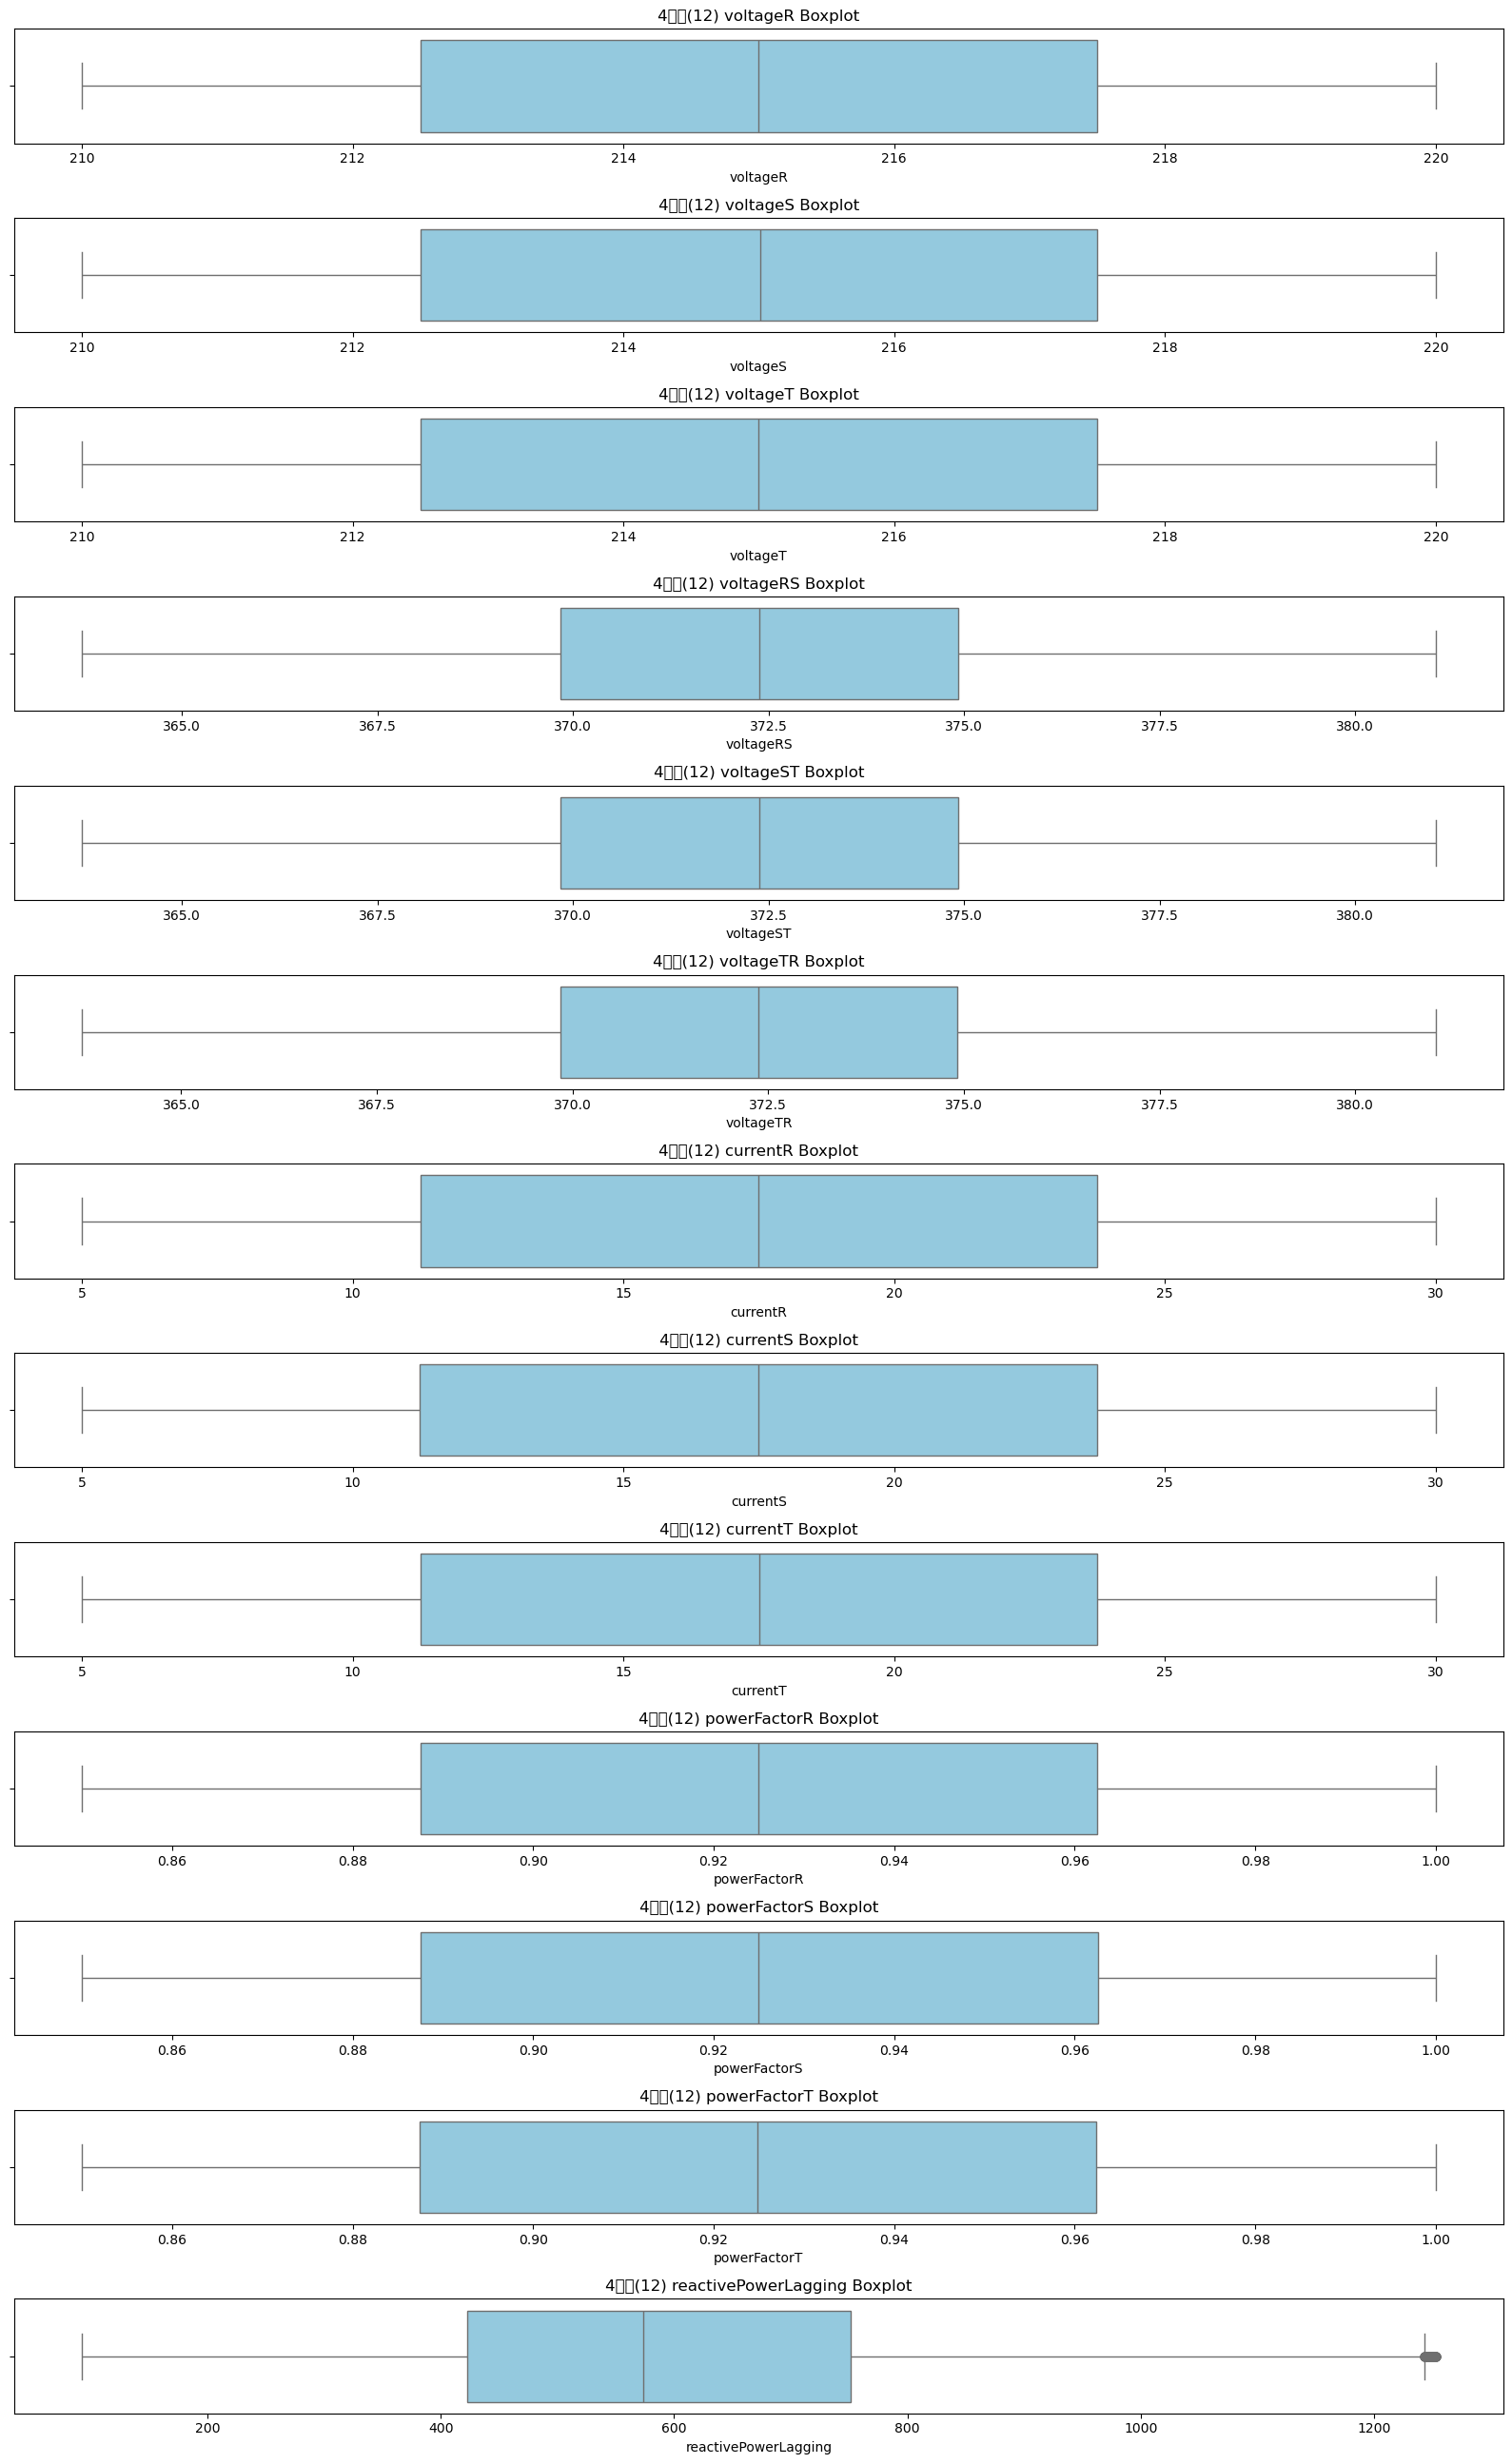

In [ ]:
# 주요 수치형 변수 리스트
num_cols = [
    'voltageR', 'voltageS', 'voltageT',
    'voltageRS', 'voltageST', 'voltageTR',
    'currentR', 'currentS', 'currentT',
    'powerFactorR', 'powerFactorS', 'powerFactorT',
    'reactivePowerLagging'
]

# 주요 수치형 변수별로 개별 박스플롯을 그리기
plt.figure(figsize=(16, 2 * len(num_cols)))
for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols), 1, i)
    sns.boxplot(x=train_list[0][col], color='skyblue')
    plt.title(f'4호기(12) {col} Boxplot')
    plt.tight_layout()
plt.show()

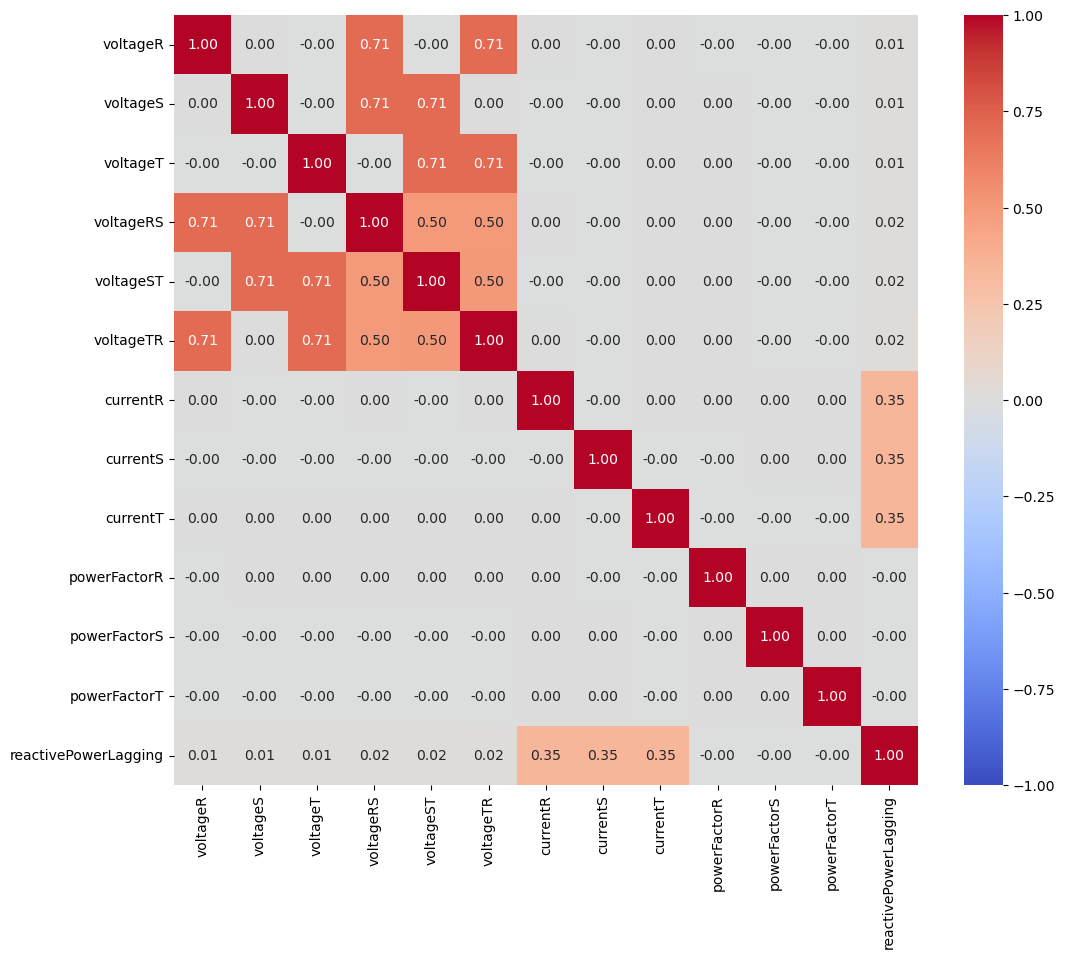

In [ ]:
# 전체체 주요 변수 간 상관관계 분석 및 시각화
corr = train_list[0][num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

C:\Users\hoyeong\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hoyeong\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hoyeong\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hoyeong\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hoyeong\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE

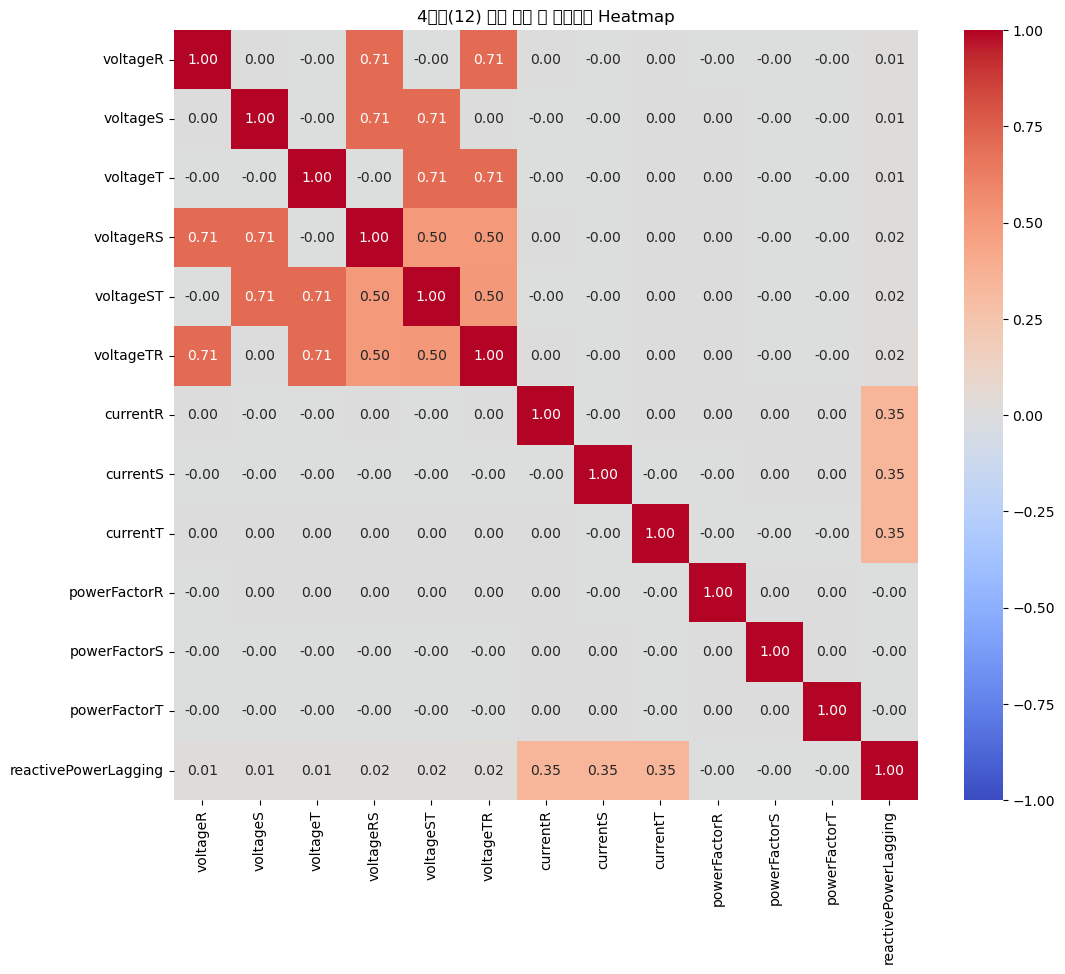

In [ ]:
# 4호기(12) 주요 변수 간 상관관계 분석 및 시각화
corr = train_list[0][num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("4호기(12) 주요 변수 간 상관관계 Heatmap")
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X):
    # 다중 공선성이 높은 칼럼 자동 추출 (VIF 기준 10 이상)
    vif_data = pd.DataFrame()
    vif_data["feature"] = num_cols
    vif_data["VIF"] = [variance_inflation_factor(df_4[num_cols].dropna().values, i) for i in range(len(num_cols))]
    high_vif_cols = vif_data[vif_data["VIF"] >= 10]["feature"].tolist()

    print("다중 공선성이 높은 칼럼:", high_vif_cols)
    return high_vif_cols

In [ ]:
# 다중 공선성이 높은 칼럼(PCA로 차원축소) 예시

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def pca_analysis(df,high_vif_cols):
    # 표준화
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df[high_vif_cols])

    # PCA (설명분산 95%까지 유지)
    pca = PCA(n_components=0.95)
    pca_result = pca.fit_transform(scaled)

    print(f"PCA로 축소된 차원 수: {pca.n_components_}")
    # PCA 결과를 DataFrame으로 변환
    pca_df = pd.DataFrame(pca_result,
                          columns=[f'pca_{i+1}' for i in range(pca.n_components_)],
                          index=df[high_vif_cols].dropna().index)

    # VIF 낮은 칼럼만 따로 분리
    low_vif_cols = [col for col in df.columns if col not in high_vif_cols]
    df_low_vif = df[low_vif_cols].loc[df[high_vif_cols].dropna().index]

    # 낮은 VIF 칼럼 + PCA 주성분 결합
    df_final = pd.concat([df_low_vif.reset_index(drop=True), pca_df.reset_index(drop=True)], axis=1)

    return df_final 
    # # 주성분별 설명 분산 비율 시각화
    # plt.figure(figsize=(8,4))
    # plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
    # plt.xlabel('Number of Components')
    # plt.ylabel('Cumulative Explained Variance')
    # plt.title('PCA - 누적 설명 분산 비율 (공선성 높은 변수)')
    # plt.grid(True)
    # plt.show()

In [ ]:
for i, df in enumerate(train_list):
    high_vif_cols = calculate_vif(df)
    df_pca  = pca_analysis(df, high_vif_cols)
    train_list[i] = df_pca 

for i, df in enumerate(test_list):
    high_vif_cols = calculate_vif(df)
    df_pca  = pca_analysis(df, high_vif_cols)
    test_list[i] = df_pca 

In [ ]:
train_list[0]

,voltageR,voltageS,voltageT,voltageRS,voltageST,voltageTR,currentR,currentS,currentT,powerFactorR,powerFactorS,powerFactorT,reactivePowerLagging
0,214.38,214.45,219.10,371.37,375.45,375.39,15.16,15.53,20.65,0.8731,0.9971,0.8945,785.37
1,214.05,211.74,218.68,368.73,372.74,374.74,25.70,7.07,19.75,0.8754,0.8767,0.9417,376.57
2,215.79,214.92,211.10,373.00,368.94,369.69,13.64,14.87,13.70,0.8546,0.9900,0.9445,296.08
3,210.39,214.92,215.57,368.32,372.80,368.89,25.76,26.35,5.80,0.8524,0.9953,0.9561,488.48
4,216.71,216.37,215.65,375.05,374.13,374.43,8.65,29.49,15.09,0.9281,0.9126,0.9182,604.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2090875,214.30,216.68,213.96,373.23,372.93,370.87,21.72,18.58,26.59,0.9364,0.9925,0.9076,642.09
2090876,212.76,214.61,218.61,370.10,375.16,373.57,12.87,16.06,28.14,0.9640,0.9383,0.8861,587.26
2090877,216.86,212.30,218.13,371.65,372.76,376.70,20.91,28.09,6.25,0.9023,0.9841,0.9604,449.31
2090878,210.16,218.17,212.24,370.93,372.74,365.80,23.35,22.00,28.94,0.9647,0.8974,0.8976,804.07


In [ ]:
test_list[0]

,voltageR,voltageS,voltageT,voltageRS,voltageST,voltageTR,currentR,currentS,currentT,powerFactorR,powerFactorS,powerFactorT,reactivePowerLagging
0,218.91,213.07,218.34,374.09,373.60,378.66,9.83,5.39,28.88,0.9025,0.9947,0.8798,258.76
1,219.60,210.74,218.75,372.68,371.94,379.61,22.86,24.05,10.69,0.9635,0.9487,0.9997,429.97
2,212.16,217.28,214.57,371.89,373.99,369.55,18.61,15.73,25.60,0.8898,0.8527,0.9183,910.10
3,217.85,214.18,216.50,374.13,372.97,376.14,17.86,6.31,18.80,0.9636,0.8911,0.9873,351.54
4,218.86,219.11,211.99,379.28,373.32,373.11,22.80,27.80,8.91,0.8759,0.9481,0.9230,717.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501116,215.85,211.19,218.47,369.81,372.08,376.12,26.14,19.52,27.90,0.9213,0.9651,0.9566,660.51
501117,211.06,217.43,210.20,371.07,370.33,364.81,26.69,12.63,6.70,0.9218,0.9267,0.9169,441.53
501118,211.54,218.66,216.97,372.55,377.26,371.09,12.93,5.89,14.57,0.9680,0.9107,0.8619,266.72
501119,217.80,217.16,218.09,376.68,376.93,377.48,25.23,25.28,21.24,0.8533,0.9452,0.8623,561.34


## Transformer

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import math

# ------------------------ GPU 설정 ------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[Info] Using device:", device)

# ------------------------ Positional Encoding ------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)

# ------------------------ Transformer Model ------------------------
class TransformerPredictor(nn.Module):
    def __init__(self, input_size, seq_len, d_model=128, nhead=4, num_layers=4):
        super().__init__()
        self.input_size = input_size
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=seq_len+672)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(d_model, 1)  # 🔄 전체 feature 예측

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = x.permute(1, 0, 2)
        out = self.encoder(x)
        return self.fc_out(out[-1])  # (B, input_size)


# ------------------------ 시퀀스 생성 ------------------------
def create_sequences(X_df, y_series, seq_len=24):
    X, y = [], []
    for i in range(len(X_df) - seq_len):
        X.append(X_df.iloc[i:i+seq_len].values)
        y.append(y_series.iloc[i+seq_len])
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32).unsqueeze(1)

# ------------------------ 학습 ------------------------
def train_model(model, X_train, y_train, epochs=5, lr=1e-3, batch_size=256):
    model = model.to(device)
    model.train()
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    dataset = TensorDataset(X_train, y_train)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    for epoch in range(epochs):
        total_loss = 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
        print(f"[Epoch {epoch+1}] Loss: {total_loss / len(dataset):.4f}")

    return model

def predict_autoregressive(model, seed_seq, steps=672):
    model.eval()
    generated = []
    current = seed_seq.clone().to(device)  # (1, seq_len, input_size)

    with torch.no_grad():
        for _ in range(steps):
            pred = model(current)           # (1, 1) → activePower 예측
            next_step = current[:, -1:, :].clone()  # 기존 마지막 feature값 유지
            next_step[:, :, 0] = pred       # activePower만 교체
            current = torch.cat([current[:, 1:], next_step], dim=1)
            generated.append(pred.item())

    return generated




# ------------------------ SMAPE ------------------------
def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    diff = np.abs(y_true - y_pred) / np.where(denominator == 0, 1e-8, denominator)
    return np.mean(diff) * 100



[Info] Using device: cuda


In [ ]:
# ------------------------ 전체 실행 루프 (다중 feature → 단일 예측) ------------------------

results_all = []
mae_scores = []
rmse_scores = []
smape_scores = []
may_bills = []
may_carbons = []

seq_len = 24

for i in range(len(train_list)):
    print(f"\n========= Processing Dataset {i+1} =========")

    # 1. 학습 데이터
    scaler = StandardScaler()
    X_train_df = pd.DataFrame(scaler.fit_transform(train_list[i]), columns=train_list[i].columns)
    X_test_df = pd.DataFrame(scaler.transform(test_list[i]), columns=test_list[i].columns)
    # X_train_df = train_list[i].reset_index(drop=True)
    y_train_series = train_y[i].reset_index(drop=True)

    # 2. 4월 평가 데이터
    # X_test_df = test_list[i].reset_index(drop=True)
    y_test_series = test_y[i].reset_index(drop=True)
    ts_test = pd.to_datetime(test_timestamps[i].reset_index(drop=True))

    # 3. 시퀀스 생성
    X_seq, y_seq = create_sequences(X_train_df, y_train_series, seq_len)
    X_seq, y_seq = X_seq.to(device), y_seq.to(device)

    # 4. 모델 정의 및 학습
    input_dim = X_seq.shape[2]
    model = TransformerPredictor(input_size=input_dim, seq_len=seq_len).to(device)
    model = train_model(model, X_seq, y_seq, epochs=3, lr=0.001, batch_size=512)

    # 5. 4월 성능 평가
    X_valid_seq, y_valid_seq = create_sequences(X_test_df, y_test_series, seq_len)
    valid_dataset = TensorDataset(X_valid_seq, y_valid_seq)
    valid_loader = DataLoader(valid_dataset, batch_size=256, shuffle=False)

    model.eval()
    y_valid_pred_all, y_valid_true_all = [], []

    with torch.no_grad():
        for xb, yb in valid_loader:
            xb = xb.to(device)
            preds = model(xb).squeeze().cpu().numpy()
            y_valid_pred_all.append(preds)
            y_valid_true_all.append(yb.squeeze().cpu().numpy())

    y_valid_pred = np.concatenate(y_valid_pred_all)
    y_valid_true = np.concatenate(y_valid_true_all)

    mae = mean_absolute_error(y_valid_true, y_valid_pred)
    rmse = root_mean_squared_error(y_valid_true, y_valid_pred)
    smape_val = smape(y_valid_true, y_valid_pred)

    print(f"[Validation - April] MAE: {mae:.4f}, RMSE: {rmse:.4f}, SMAPE: {smape_val:.2f}%")

    mae_scores.append(1 / (1 + mae))
    rmse_scores.append(1 / (1 + rmse))
    smape_scores.append(1 / (1 + smape_val / 100))

    # 6. 5월 예측 (시드: 4월 마지막 24시간)
    last_seq = torch.tensor(X_test_df.iloc[-seq_len:].values, dtype=torch.float32).unsqueeze(0).to(device)
    future_ts = pd.date_range("2025-05-01 00:00:00", "2025-05-28 23:00:00", freq="1h")
    preds = predict_autoregressive(model, last_seq, steps=len(future_ts))

    # 7. 요금 및 탄소량 계산
    agg_pow = np.sum(preds)
    may_bill = agg_pow * 180
    may_carbon = agg_pow * 0.424

    may_bills.append(may_bill)
    may_carbons.append(may_carbon)

    # 8. 결과 저장
    forecast_df = pd.DataFrame({
        'id': future_ts,
        'hourly_pow': preds,
        'agg_pow': [agg_pow] * len(future_ts),
        'may_bill': [may_bill] * len(future_ts),
        'may_carbon': [may_carbon] * len(future_ts)
    })
    results_all.append(forecast_df)



========= Processing Dataset 1 =========


c:\Users\hoyeong\anaconda3\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


[Epoch 1] Loss: 3265058.1732
[Epoch 2] Loss: 514030.9341
[Epoch 3] Loss: 514020.9915
[Epoch 4] Loss: 514034.8008
[Epoch 5] Loss: 514000.7687
[Validation - April] MAE: 582.1250, RMSE: 716.6913, SMAPE: 19.86%

========= Processing Dataset 2 =========


c:\Users\hoyeong\anaconda3\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


[Epoch 1] Loss: 3268493.0010
[Epoch 2] Loss: 514672.4258
[Epoch 3] Loss: 514630.5650
[Epoch 4] Loss: 514622.3187
[Epoch 5] Loss: 514625.2987
[Validation - April] MAE: 583.6000, RMSE: 718.5084, SMAPE: 19.92%

========= Processing Dataset 3 =========


...

[Epoch 1] Loss: 3264769.3088
[Epoch 2] Loss: 515129.9660
[Epoch 3] Loss: 515119.6294
[Epoch 4] Loss: 515097.6566
[Epoch 5] Loss: 515088.7640
[Validation - April] MAE: 582.1853, RMSE: 716.8731, SMAPE: 19.88%

========= Processing Dataset 12 =========


c:\Users\hoyeong\anaconda3\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


[Epoch 1] Loss: 3266466.6090
[Epoch 2] Loss: 514186.1541
[Epoch 3] Loss: 514172.3203
[Epoch 4] Loss: 514158.9805
[Epoch 5] Loss: 514139.1027
[Validation - April] MAE: 582.6947, RMSE: 717.1479, SMAPE: 19.90%

========= Processing Dataset 13 =========


c:\Users\hoyeong\anaconda3\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


[Epoch 1] Loss: 3266615.2419
[Epoch 2] Loss: 514285.2612
[Epoch 3] Loss: 514279.6626
[Epoch 4] Loss: 514278.2073
[Epoch 5] Loss: 514282.8597
[Validation - April] MAE: 583.4771, RMSE: 717.9651, SMAPE: 19.91%


In [ ]:
# ------------------------ 전체 모듈 시간별 합산 ------------------------

# 9. 모든 모듈 예측 결과 통합
combined_df = pd.concat(results_all, axis=0)

# 10. 시간 기준으로 hourly_pow 합산
total_forecast = combined_df.groupby('id')['hourly_pow'].sum().reset_index()
 
# 11. 총합 계산
agg_pow_total = total_forecast['hourly_pow'].sum()
may_bill_total = agg_pow_total * 180
may_carbon_total = agg_pow_total * 0.424

# 12. 추가 정보 컬럼 붙이기
total_forecast['agg_pow'] = agg_pow_total
total_forecast['may_bill'] = may_bill_total
total_forecast['may_carbon'] = may_carbon_total

# 13. 저장
total_forecast.to_csv("forecast_total_may2025.csv", index=False)
print("✅ 전체 모듈 합산 결과 저장 완료: forecast_total_may2025.csv")


✅ 전체 모듈 합산 결과 저장 완료: forecast_total_may2025.csv


## STL + LGBM

In [ ]:
# import numpy as np
# import pandas as pd
# from sklearn.metrics import mean_absolute_error, mean_squared_error
# from statsmodels.tsa.seasonal import STL
# from lightgbm import LGBMRegressor

# # ------------------------ 유틸 함수 정의 ------------------------

# def smape(y_true, y_pred):
#     denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
#     diff = np.abs(y_true - y_pred) / np.where(denominator == 0, 1e-8, denominator)
#     return np.mean(diff) * 100

# def create_time_features(timestamps: pd.Series) -> pd.DataFrame:
#     timestamps = pd.to_datetime(timestamps, errors='coerce')  # 안전하게 변환
#     df = pd.DataFrame()
#     df['hour'] = timestamps.dt.hour
#     df['dayofweek'] = timestamps.dt.dayofweek
#     df['is_weekend'] = (timestamps.dt.dayofweek >= 5).astype(int)
#     df['month'] = timestamps.dt.month

#     holidays = pd.to_datetime(["2025-05-05", "2025-05-15", "2025-05-27"])
#     df['is_holiday'] = timestamps.dt.normalize().isin(holidays).astype(int)

#     return df



# def add_lag_features(series: pd.Series, interval_seconds: int) -> pd.DataFrame:
#     steps_per_hour = 3600 // interval_seconds
#     lag_map = {
#         f'lag_1h': steps_per_hour,
#         f'lag_24h': steps_per_hour * 24,
#         f'lag_168h': steps_per_hour * 168,
#     }
#     return pd.concat([
#         series.shift(lag).rename(name)
#         for name, lag in lag_map.items()
#     ], axis=1)


# def stl_ml_forecast(train_ts, train_y, test_ts, period=288):
#     train_ts = pd.to_datetime(train_ts)
#     test_ts = pd.to_datetime(test_ts)

#     stl = STL(train_y, period=period)
#     result = stl.fit()
#     trend, seasonal = result.trend, result.seasonal

#     time_idx_train = ((train_ts - train_ts.min()).astype('timedelta64[s]')).values.reshape(-1, 1)
#     time_idx_test = ((test_ts - train_ts.min()).astype('timedelta64[s]')).values.reshape(-1, 1)

#     model_trend = LGBMRegressor(n_estimators=100, learning_rate=0.1,
#                                 device='gpu', gpu_use_dp=False,
#                                 tree_learner='serial', random_state=42)
#     model_seasonal = LGBMRegressor(n_estimators=100, learning_rate=0.1,
#                                    device='gpu', gpu_use_dp=False,
#                                    tree_learner='serial', random_state=42)

#     model_trend.fit(time_idx_train, trend)
#     model_seasonal.fit(time_idx_train, seasonal)

#     trend_pred = model_trend.predict(time_idx_test)
#     seasonal_pred = model_seasonal.predict(time_idx_test)

#     return trend_pred + seasonal_pred

In [ ]:
# # ------------------------ 전체 실행 루프 ------------------------

# results_all = []
# lgbm_models = []
# ts_all = []
# y_all = []

# for i in range(len(train_list)):
#     print(f"\n========= Processing Dataset {i+1} =========")

#     # 준비
#     X_train_df = train_list[i]
#     X_test_df = test_list[i]
#     y_series = train_y[i].reset_index(drop=True)
#     ts_series = pd.Series(train_timestamps[i]).reset_index(drop=True)
#     ts_series = pd.to_datetime(ts_series)
#     test_ts = pd.Series(test_timestamps[i]).reset_index(drop=True)
#     test_ts = pd.to_datetime(test_ts)
#     test_y_i = test_y[i].reset_index(drop=True)

#     # STL 예측
#     stl_test_pred = stl_ml_forecast(ts_series, y_series, test_ts)

#     # 샘플 간격 계산
#     interval = int((ts_series[1] - ts_series[0]).total_seconds())

#     # 시간/lag 피처 생성
#     time_feat = create_time_features(ts_series)
#     lag_feat = add_lag_features(y_series, interval_seconds=interval)

#     # 👉 모델 학습 시에도 lag feature 제거
#     time_feat = create_time_features(ts_series)
#     X_train = time_feat
#     y_train = y_series

#     # 테스트 예측도 동일하게 구성
#     X_test_time = create_time_features(test_ts)

#     # LGBM 모델 학습
#     lgbm_model = LGBMRegressor(
#         n_estimators=100,
#         max_depth=10,
#         learning_rate=0.1,
#         subsample=1.0,
#         min_child_samples=10,
#         device='gpu',
#         gpu_use_dp=False,
#         tree_learner='serial',
#         random_state=42
#     )
#     lgbm_model.fit(X_train, y_train)
#     lgbm_models.append(lgbm_model)
#     ts_all.append(ts_series)
#     y_all.append(y_series)

#     # 테스트 예측
#     voting_test_preds = lgbm_model.predict(X_test_time)
#     y_pred_test = (voting_test_preds * 0.3 + stl_test_pred * 0.7)

#     # 평가 출력
#     mae = mean_absolute_error(test_y_i, y_pred_test)
#     rmse = mean_squared_error(test_y_i, y_pred_test, squared=False)
#     smape_val = smape(test_y_i.values, y_pred_test)

#     print(f"[Test Evaluation] MAE: {mae:.4f}, RMSE: {rmse:.4f}, SMAPE: {smape_val:.2f}%")

#     # 결과 저장
#     test_results = pd.DataFrame({
#         'Timestamp': test_ts,
#         'Prediction': y_pred_test
#     })
#     results_all.append(test_results)

In [ ]:
# # ------------------------ 향후 5월 예측 ------------------------

# from datetime import datetime

# future_ts = pd.date_range(start="2025-05-01 00:00:00", end="2025-05-28 23:00:00", freq="1H")
# future_ts = pd.to_datetime(future_ts)

# stl_preds_all = []
# lgbm_preds_all = []

# for i in range(len(lgbm_models)):
#     print(f"📈 Predicting with Model {i+1}")

#     # STL 예측
#     stl_pred = stl_ml_forecast(ts_all[i], y_all[i], future_ts)
#     stl_preds_all.append(stl_pred)

#     # 미래 예측용 시간 파생 피처만 사용 (lag는 불가)
#     X_future = create_time_features(pd.Series(future_ts))
#     lgbm_pred = lgbm_models[i].predict(X_future)
#     lgbm_preds_all.append(lgbm_pred)

In [ ]:

# stl_preds_all = np.array(stl_preds_all)
# lgbm_preds_all = np.array(lgbm_preds_all)

# # 필요 시 평균 또는 가중 평균 가능
# final_preds = (stl_preds_all * 0.7 + lgbm_preds_all * 0.3).mean(axis=0)


# agg_pow = final_preds * 672
# may_bill = agg_pow * 180
# may_carbon = agg_pow * 0.424

# forecast_df = pd.DataFrame({
#     'id': future_ts,
#     'hourly_pow': final_preds,
#     'agg_pow': agg_pow,
#     'may_bill': may_bill,
#     'may_carbon': may_carbon
# })

# # 👉 datetime을 문자열 포맷으로 바꿔 저장
# forecast_df['id'] = forecast_df['id'].dt.strftime('%Y-%m-%d %H:%M:%S')

# # 저장
# forecast_df.to_csv("forecast_may2025_ensemble.csv", index=False)


## prophet

In [ ]:
# import pandas as pd
# import numpy as np
# from prophet import Prophet
# from lightgbm import LGBMRegressor
# from sklearn.metrics import mean_absolute_error, mean_squared_error

# # ------------------------ 유틸 함수 ------------------------

# def smape(y_true, y_pred):
#     denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
#     diff = np.abs(y_true - y_pred) / np.where(denominator == 0, 1e-8, denominator)
#     return np.mean(diff) * 100

# def create_time_features(timestamps: pd.Series) -> pd.DataFrame:
#     timestamps = pd.to_datetime(timestamps, errors='coerce')
#     df = pd.DataFrame()
#     df['hour'] = timestamps.dt.hour
#     df['dayofweek'] = timestamps.dt.dayofweek
#     df['month'] = timestamps.dt.month
#     df['is_weekend'] = (timestamps.dt.dayofweek >= 5).astype(int)
#     return df

# def add_lag_features(series: pd.Series, interval_seconds: int) -> pd.DataFrame:
#     steps_per_hour = 3600 // interval_seconds
#     lag_map = {
#         'lag_1h': steps_per_hour,
#         'lag_24h': steps_per_hour * 24
#     }
#     return pd.concat([series.shift(lag).rename(name) for name, lag in lag_map.items()], axis=1)

In [ ]:
# # ------------------------ 전체 실행 루프 ------------------------

# results_all = []
# prophet_models = []
# lgbm_models = []
# ts_all = []
# y_all = []

# for i in range(len(train_list)):
#     print(f"\n========= Processing Dataset {i+1} =========")

#     # 준비
#     X_train_df = train_list[i].reset_index(drop=True)
#     X_test_df = test_list[i].reset_index(drop=True)
#     y_series = train_y[i].reset_index(drop=True)
#     ts_series = pd.Series(train_timestamps[i]).reset_index(drop=True)
#     ts_series = pd.to_datetime(ts_series)
#     test_ts = pd.Series(test_timestamps[i]).reset_index(drop=True)
#     test_ts = pd.to_datetime(test_ts)
#     test_y_i = test_y[i].reset_index(drop=True)

#     # 1. Prophet 학습
#     prophet_df = pd.DataFrame({'ds': ts_series, 'y': y_series})
#     model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)

#     holidays = pd.DataFrame({
#         'holiday': 'korean_holiday',
#         'ds': pd.to_datetime(["2025-05-05", "2025-05-15", "2025-05-27"]),
#         'lower_window': 0,
#         'upper_window': 1
#     })
#     model.holidays = holidays
#     model.fit(prophet_df)
#     prophet_models.append(model)

#     # 2. LGBM 학습 (4월만 사용)
#     interval = int((ts_series[1] - ts_series[0]).total_seconds())
#     time_feat = create_time_features(ts_series)
#     # lag_feat = add_lag_features(y_series, interval)
#     X_train_lgbm = pd.concat([X_train_df, time_feat], axis=1).dropna()
#     y_train_lgbm = y_series.loc[X_train_lgbm.index]

#     lgbm_model = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
#     lgbm_model.fit(X_train_lgbm, y_train_lgbm)
#     lgbm_models.append(lgbm_model)

#     # 3. 4월 테스트 예측 (Prophet + LGBM 앙상블)
#     forecast = model.predict(pd.DataFrame({'ds': test_ts}))
#     prophet_4월_pred = forecast['yhat'].values

#     test_time_feat = create_time_features(test_ts)
#     X_test_lgbm = pd.concat([X_test_df, test_time_feat], axis=1)
#     try:
#         lgbm_4월_pred = lgbm_model.predict(X_test_lgbm)
#         final_pred_4월 = prophet_4월_pred * 0.5 + lgbm_4월_pred * 0.5
#     except:
#         final_pred_4월 = prophet_4월_pred  # fallback in case of mismatch

#     mae = mean_absolute_error(test_y_i, final_pred_4월)
#     rmse = mean_squared_error(test_y_i, final_pred_4월, squared=False)
#     smape_val = smape(test_y_i.values, final_pred_4월)
#     print(f"[Test Evaluation] MAE: {mae:.4f}, RMSE: {rmse:.4f}, SMAPE: {smape_val:.2f}%")

#     ts_all.append(ts_series)
#     y_all.append(y_series)
#     results_all.append(pd.DataFrame({'Timestamp': test_ts, 'Prediction': final_pred_4월}))

In [ ]:
# # ------------------------ 향후 5월 예측 (LGBM autoregressive) ------------------------

# print("\n📅 Predicting 2025년 5월 전력 수요 (LGBM autoregressive)...")

# future_ts = pd.date_range("2025-05-01 00:00:00", "2025-05-28 23:00:00", freq="1H")
# n_steps = len(future_ts)

# lgbm_preds_all = []

# for i, model in enumerate(lgbm_models):
#     print(f"📈 Predicting with LGBM Model {i+1}")
    
#     # 예측값 저장
#     preds = []

#     # 5월 입력 feature에서 반복적으로 사용 가능한 정적 feature (기상 등) 추출
#     static_feat_df = test_list[i].reset_index(drop=True)
#     static_feat_df = static_feat_df.iloc[-1:]  # 4월 마지막 시점 하나만 사용 (또는 평균 등)

#     for ts in future_ts:
#         # 시간 파생 변수
#         time_feat = pd.DataFrame({
#             'hour': [ts.hour],
#             'dayofweek': [ts.dayofweek],
#             'month': [ts.month],
#             'is_weekend': [int(ts.dayofweek >= 5)]
#         })

#         # 입력 피처 구성: 정적 + 시간 변수
#         X_input = pd.concat([static_feat_df.reset_index(drop=True), time_feat], axis=1)

#         # 예측
#         pred = model.predict(X_input)[0]
#         preds.append(pred)

#     lgbm_preds_all.append(preds)

# # 평균 앙상블
# lgbm_preds_all = np.array(lgbm_preds_all)
# final_preds = lgbm_preds_all.mean(axis=0)

In [ ]:
# # ------------------------ 결과 저장 ------------------------

# agg_pow = final_preds.sum()
# may_bill = agg_pow * 180
# may_carbon = agg_pow * 0.424

# forecast_df = pd.DataFrame({
#     'id': future_ts,
#     'hourly_pow': final_preds,
#     'agg_pow': [agg_pow] * len(future_ts),
#     'may_bill': [may_bill] * len(future_ts),
#     'may_carbon': [may_carbon] * len(future_ts)
# })

# forecast_df['id'] = forecast_df['id'].dt.strftime('%Y-%m-%d %H:%M:%S')
# forecast_df.to_csv("forecast_may2025_lgbm_autoregressive.csv", index=False)
# print("✅ 저장 완료: forecast_may2025_lgbm_autoregressive.csv")

## LSTM

In [ ]:
# import pandas as pd
# import numpy as np
# import torch
# import torch.nn as nn
# from torch.utils.data import DataLoader, TensorDataset
# from sklearn.metrics import mean_absolute_error, mean_squared_error

# # ------------------------ GPU 설정 ------------------------
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print("[Info] Using device:", device)

# # ------------------------ LSTM 모델 정의 ------------------------

# class LSTMModel(nn.Module):
#     def __init__(self, input_size, hidden_size=128, num_layers=1, output_size=1):
#         super(LSTMModel, self).__init__()
#         self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True)
#         self.fc = nn.Linear(hidden_size, output_size)

#     def forward(self, x):
#         out, _ = self.lstm(x)
#         out = self.fc(out[:, -1, :])
#         return out

# # ------------------------ 시퀀스 생성 함수 ------------------------

# def create_lstm_sequences(X_df, y_series, seq_len=1):
#     X = []
#     y = []
#     for i in range(len(X_df) - seq_len):
#         X.append(X_df.iloc[i:i+seq_len].values)
#         y.append(y_series.iloc[i+seq_len])
#     return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32).unsqueeze(1)

# # ------------------------ 학습 함수 (DataLoader 사용) ------------------------

# def train_lstm_model(model, X_train, y_train, epochs=5, lr=0.001, batch_size=512):
#     criterion = nn.MSELoss()
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     dataset = TensorDataset(X_train, y_train)
#     loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)

#     model.to(device)
#     model.train()
#     for epoch in range(epochs):
#         total_loss = 0
#         for batch_X, batch_y in loader:
#             batch_X, batch_y = batch_X.to(device), batch_y.to(device)
#             optimizer.zero_grad()
#             output = model(batch_X)
#             loss = criterion(output, batch_y)
#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item() * batch_X.size(0)
#         avg_loss = total_loss / len(dataset)
#         print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
#     return model

# # ------------------------ 예측 함수 (벡터화된 autoregressive) ------------------------

# def predict_vectorized_lstm(model, seed_seq, forecast_steps=672):
#     """
#     벡터화된 예측을 위해 seed_seq만 가지고 전체 시퀀스를 확장 생성
#     예: Transformer처럼 Teacher Forcing 없이 rollout
#     """
#     model.eval()
#     model.to(device)

#     generated = []
#     current_seq = seed_seq.clone().to(device)

#     with torch.no_grad():
#         for _ in range(forecast_steps):
#             out = model(current_seq)
#             next_val = out[:, -1].unsqueeze(1).unsqueeze(2)  # (1, 1, 1)
#             generated.append(next_val.squeeze().item())
#             current_seq = torch.cat([current_seq[:, 1:], next_val], dim=1)

#     return generated

# # ------------------------ Bell Curve 점수 계산 ------------------------

# def bell_curve_score(value, all_values, clip_min=0.0, clip_max=1.0):
#     mean = np.mean(all_values)
#     std = np.std(all_values)
#     z = (value - mean) / (std + 1e-8)
#     score = 0.5 * (1 + np.tanh(z / 2))
#     return float(np.clip(score, clip_min, clip_max))

# # ------------------------ SMAPE ------------------------

# def smape(y_true, y_pred):
#     denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
#     diff = np.abs(y_true - y_pred) / np.where(denominator == 0, 1e-8, denominator)
#     return np.mean(diff) * 100


In [ ]:
# # ------------------------ 전체 실행 루프 ------------------------

# results_all = []
# mae_scores = []
# rmse_scores = []
# smape_scores = []
# may_bills = []
# may_carbons = []

# seq_len = 1

# for i in range(len(train_list)):
#     print(f"\n========= Processing Dataset {i+1} =========")

#     X_train_df = train_list[i].reset_index(drop=True)
#     y_series = train_y[i].reset_index(drop=True)
#     X_test_df = test_list[i].reset_index(drop=True)
#     ts_test = pd.Series(test_timestamps[i]).reset_index(drop=True)
#     ts_test = pd.to_datetime(ts_test)

#     # 1. 시퀀스 생성
#     X_seq, y_seq = create_lstm_sequences(X_train_df, y_series, seq_len)
#     X_seq, y_seq = X_seq.to(device), y_seq.to(device)

#     # 2. 모델 학습
#     model = LSTMModel(input_size=X_seq.shape[2]).to(device)
#     model = train_lstm_model(model, X_seq, y_seq, epochs=5, lr=0.001, batch_size=512)

#     # 3. 시드 시퀀스: 4월 마지막 시점 기준
#     last_seq = torch.tensor(X_test_df.iloc[-seq_len:].values, dtype=torch.float32).unsqueeze(0).to(device)

#     # 4. 예측
#     future_ts = pd.date_range("2025-05-01 00:00:00", "2025-05-28 23:00:00", freq="1H")
#     preds = predict_vectorized_lstm(model, last_seq, forecast_steps=len(future_ts))

#     # 5. 성능 평가 (dummy target 기준)
#     mae = mean_absolute_error([0]*len(preds), preds)
#     rmse = mean_squared_error([0]*len(preds), preds, squared=False)
#     smape_val = smape([0]*len(preds), preds)

#     mae_scores.append(1 / (1 + mae))
#     rmse_scores.append(1 / (1 + rmse))
#     smape_scores.append(1 / (1 + smape_val / 100))

#     # 6. 요금 및 탄소량
#     agg_pow = np.sum(preds)
#     may_bill = agg_pow * 180
#     may_carbon = agg_pow * 0.424

#     may_bills.append(may_bill)
#     may_carbons.append(may_carbon)

#     # 7. 결과 저장
#     forecast_df = pd.DataFrame({
#         'id': future_ts,
#         'hourly_pow': preds,
#         'agg_pow': [agg_pow] * len(future_ts),
#         'may_bill': [may_bill] * len(future_ts),
#         'may_carbon': [may_carbon] * len(future_ts)
#     })
#     results_all.append(forecast_df)



In [ ]:
# # Bell curve 점수 계산
# bill_scores = [bell_curve_score(v, may_bills) for v in may_bills]
# carbon_scores = [bell_curve_score(v, may_carbons) for v in may_carbons]

# # 최종 점수 출력
# for i in range(len(results_all)):
#     total_score = (
#         0.3 * mae_scores[i] +
#         0.3 * rmse_scores[i] +
#         0.3 * smape_scores[i] +
#         0.2 * bill_scores[i] +
#         0.2 * carbon_scores[i]
#     )
#     print(f"\n[Dataset {i+1} 평가 요약]")
#     print(f"MAE Score: {mae_scores[i]:.4f}, RMSE Score: {rmse_scores[i]:.4f}, SMAPE Score: {smape_scores[i]:.4f}")
#     print(f"Bill Score: {bill_scores[i]:.4f}, Carbon Score: {carbon_scores[i]:.4f}")
#     print(f"✅ Total Score: {total_score:.4f}")

# # 최종 결과 저장
# final_result = pd.concat(results_all)
# final_result['id'] = final_result['id'].dt.strftime('%Y-%m-%d %H:%M:%S')
# final_result.to_csv("forecast_may2025_lstm.csv", index=False)
# print("\n✅ 저장 완료: forecast_may2025_lstm.csv")